In [ ]:
# !env | grep TPU

In [ ]:
# !python -c "import jax; [print(f'TPU {d.id} | Used Memory: {d.memory_stats().get(\"bytes_in_use\", 0)/1024**3:.2f} GB / Total Memory: {d.memory_stats().get(\"bytes_limit\", 1)/1024**3:.2f} GB') for d in jax.devices()]"

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
2026-03-26 16:40:00.661077: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774543200.692432    1619 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774543200.702030    1619 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774543200.739667    1619 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid link

Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading base UNet CONFIG to create a structural template...


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch cla

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or audit

Generating image for prompt: 'A drawing of Kakashi Hatake'...


  0%|          | 0/50 [00:00<?, ?it/s]

Done! Here is your PyTorch-generated image:


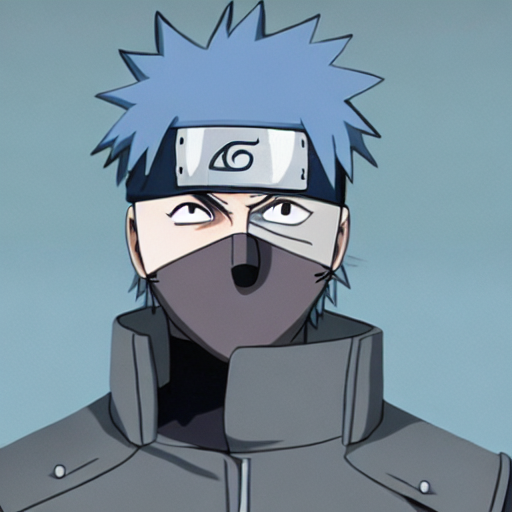

In [1]:
import torch
import jax
from diffusers import FlaxUNet2DConditionModel, UNet2DConditionModel, StableDiffusionPipeline
from flax.training import checkpoints
from huggingface_hub import snapshot_download
from IPython.display import display

BASE_REPO_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

# 1. Download raw Flax checkpoint from Hugging Face
repo_id = "NiceWang/sd-naruto-tpu"
print(f"Downloading raw Flax checkpoint from {repo_id}...")
ckpt_dir = snapshot_download(repo_id=repo_id)

# 2. Create A  dummy target template
print("Loading base UNet CONFIG to create a structural template...")
config = FlaxUNet2DConditionModel.load_config(BASE_REPO_ID, subfolder="unet")
flax_unet = FlaxUNet2DConditionModel.from_config(config)

# Generate dummy parameters just to get the exact dictionary structure for Orbax
key = jax.random.PRNGKey(0)
dummy_params = flax_unet.init_weights(key)
target_template = {"params": dummy_params}

# 3. Restore and unshard fine-tuned weights using the dummy template
print("Restoring sharded checkpoint into single-device memory...")
raw_ckpt = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=target_template)
fine_tuned_unet_params = raw_ckpt["params"]

# Save it to a temporary local folder with fine-tuned params
print("Converting raw weights to standard Diffusers format...")
temp_flax_dir = "./temp_flax_unet"
flax_unet.save_pretrained(temp_flax_dir, params=fine_tuned_unet_params)

# # 4. Load into PyTorch
# print("Loading Flax weights into PyTorch UNet...")
# pt_unet = UNet2DConditionModel.from_pretrained(
#     temp_flax_dir, 
#     from_flax=True, 
#     torch_dtype=torch.float16
# )

# 4. Load into PyTorch
print("Loading Flax weights into PyTorch UNet manually...")

from diffusers.models.modeling_pytorch_flax_utils import load_flax_checkpoint_in_pytorch_model

# a. Initialize a blank PyTorch UNet using the structure from config
pt_unet = UNet2DConditionModel.from_config(temp_flax_dir)

# b. Use the internal Diffusers tool to safely inject the Flax .msgpack weights
msgpack_file = f"{temp_flax_dir}/diffusion_flax_model.msgpack"
pt_unet = load_flax_checkpoint_in_pytorch_model(pt_unet, msgpack_file)

# c. Cast it to float16 for optimal GPU inference
pt_unet = pt_unet.to(torch.float16)

# 5. Run Inference on GPU using PyTorch
print("Setting up PyTorch Stable Diffusion Pipeline on GPU...")
pipe = StableDiffusionPipeline.from_pretrained(
    BASE_REPO_ID, 
    torch_dtype=torch.float16,
    safety_checker=None
)
pipe.unet = pt_unet
pipe = pipe.to("cuda")

prompt = "A drawing of Kakashi Hatake"
print(f"Generating image for prompt: '{prompt}'...")

image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]

print("Done! Here is your PyTorch-generated image:")
display(image)

In [ ]:
# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()
# # secret_value_0 = user_secrets.get_secret("HF_TOKEN")
# hf_token = user_secrets.get_secret("HF_TOKEN_WRITE")

In [ ]:
# from huggingface_hub import HfApi, login

# # 1. Login to Hugging Face (replace this string with your WRITE access token)
# login(token=hf_token)

# # 2. Set the repository ID for Hugging Face
# repo_id = "NiceWang/sd-naruto-tpu-float32"

# # 3. Initialize the API and create the repository (it will safely skip if it already exists)
# api = HfApi()
# api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)
# print(f"Repository '{repo_id}' is ready!")

# # 4. Specify the folder path containing your fine-tuned weights
# folder_path = "/kaggle/working/model_naruto_float32" 

# # 5. Start uploading the entire folder
# print("Uploading model weights to Hugging Face, please wait...")
# api.upload_folder(
#     folder_path=folder_path,
#     repo_id=repo_id,
#     repo_type="model",
#     commit_message="Upload fine-tuned Naruto SD model from Kaggle TPU"
# )

# print(f"Upload successful! Check it out on your Hugging Face profile: https://huggingface.co/{repo_id}")

In [ ]:
# import os
# from huggingface_hub import HfApi, login

# login(token=hf_token)

# repo_id = "NiceWang/sd-naruto-tpu"

# api = HfApi()
# api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)

# # Walk and upload each file individually as-is, no conversion
# for root, dirs, files in os.walk("/kaggle/input/notebooks/nicecaliforniaw/sd-tpu-demo/model_naruto"):
#     for f in files:
#         local_path = os.path.join(root, f)
#         # Preserve relative path structure in the repo
#         relative_path = os.path.relpath(local_path, "/kaggle/input/notebooks/nicecaliforniaw/sd-tpu-demo/model_naruto")
#         print(f"Uploading {relative_path}...")
#         api.upload_file(
#             path_or_fileobj=local_path,
#             path_in_repo=relative_path,
#             repo_id=repo_id,
#             repo_type="model",
#         )

# print("Done! Original format preserved.")

In [ ]:
# import os
# import numpy as np
# import jax
# import jax.numpy as jnp
# import orbax.checkpoint as ocp
# from huggingface_hub import HfApi, login

# MODEL_PATH = "/kaggle/input/notebooks/nicecaliforniaw/sd-tpu-demo/model_naruto"

# # Find checkpoint subdirectory
# ckpt_subdir = None
# for name in sorted(os.listdir(MODEL_PATH)):
#     full = os.path.join(MODEL_PATH, name)
#     if os.path.isdir(full) and name.startswith("checkpoint_"):
#         ckpt_subdir = full
#         break
# print(f"Found: {ckpt_subdir}")

# # Load with orbax (we have enough RAM here, not loading any model alongside)
# checkpointer = ocp.PyTreeCheckpointer()
# raw = checkpointer.restore(ckpt_subdir)
# print("Top-level keys:", raw.keys())

# # Flatten nested dict to save as npz
# flat_params = {}
# def flatten(d, prefix=""):
#     for k, v in d.items():
#         full_key = f"{prefix}/{k}" if prefix else k
#         if isinstance(v, dict):
#             flatten(v, full_key)
#         else:
#             flat_params[full_key] = np.array(v, dtype=np.float32)

# flatten(raw["params"])
# print(f"Total arrays: {len(flat_params)}")

# # Save as single npz file
# out_path = "/kaggle/working/unet_naruto_bf16.npz"
# np.savez(out_path, **flat_params)
# print(f"Saved: {os.path.getsize(out_path)/1e9:.2f} GB")

In [ ]:
# # Upload to HF
# login(token=hf_token)
# api = HfApi()
# api.upload_file(
#     path_or_fileobj=out_path,
#     path_in_repo="unet_naruto_bf16.npz",
#     repo_id="NiceWang/sd-naruto-tpu",
#     repo_type="model",
#     commit_message="Add npz format weights for easier loading",
# )
# print("Upload done!")